In [1]:
from pathlib import Path
import sys

here = Path.cwd().resolve()
repo_root = here
while (
    repo_root != repo_root.parent
    and not (repo_root / "src" / "ecg_chagas_embeddings").exists()
):
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root / "src"))
print("Using repo_root:", repo_root)

from ecg_chagas_embeddings.data.prepare_dataset import (  # noqa: E402
    butter_filter,
    resample_ecg,
    subtract_channel_medians,
    softclip_scale_ecg,
    normalize_per_lead,
)


Using repo_root: /home/flo178/projects/master-thesis/ecg-chagas-embeddings


# Sample Quality across the Datasets
The ECG samples are noisy and have artifacts that I want to remove so the model gets clean data as input.

I use `neurokit2` package to inspect my data here with `ecg_clean()`.
There are multiple methods, the standard is a high-pass filter followed by a powerline filter.
I also use the `biosppy` here, so I can investigate whether my own implementation of a filter matches this one-channel cleaning from `neurokit2`.

Here are 4 samples across my datasets, showcasing different noise and artifacts.
I use Lead II across all samples, because it generally aligns with the heart axis and results in the tallest QRS complex ([from scienceinsights.org](https://scienceinsights.org/why-lead-ii-is-important-in-an-ecg/)).

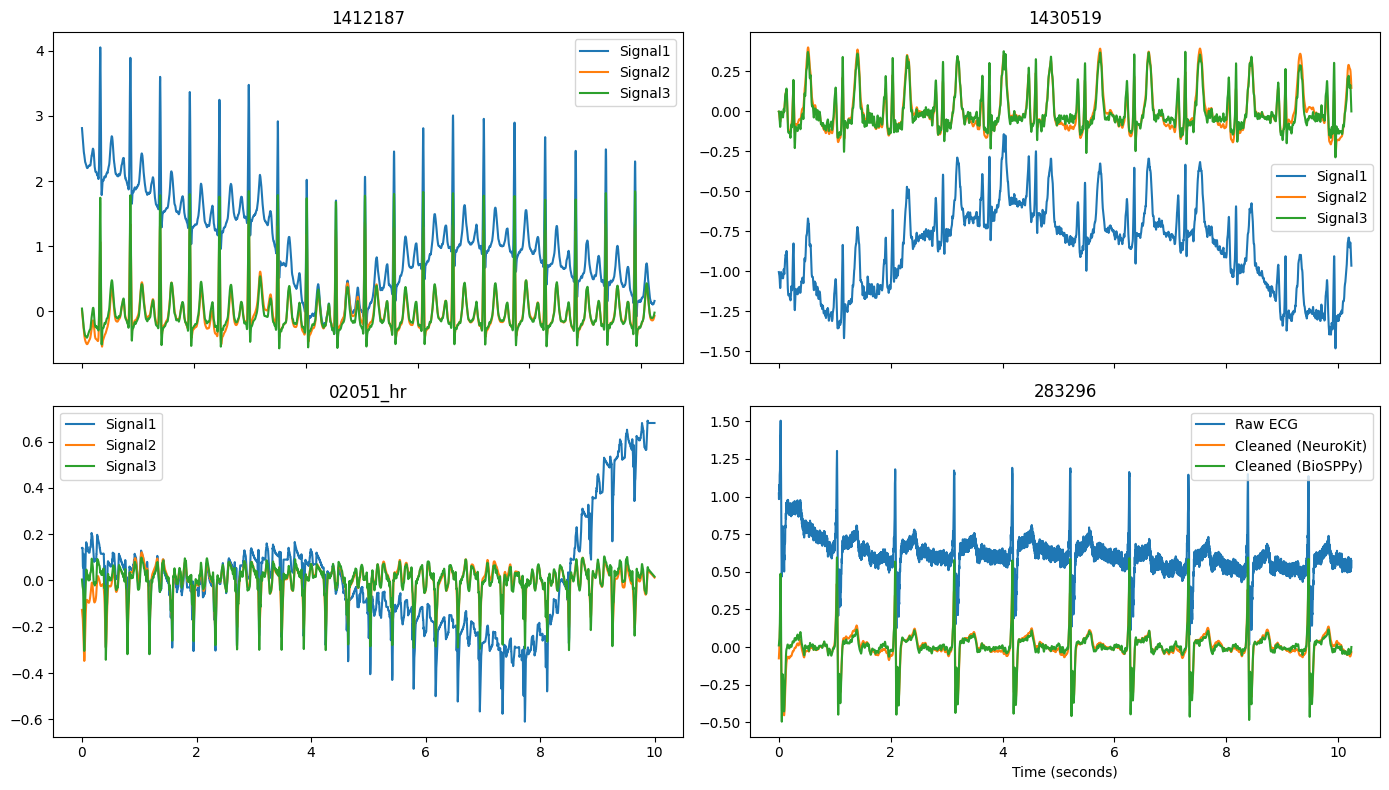

In [2]:
import wfdb
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

record_paths = [
    # baseline wandering
    "/home/flo178/projects/master-thesis/datasets/physionet2025/code15/processedMaster/exams_part4/1412187",
    # other abnormality
    "/home/flo178/projects/master-thesis/datasets/physionet2025/code15/processedMaster/exams_part4/1430519",
    # artifact in beginning
    "/home/flo178/projects/master-thesis/datasets/physionet2025/ptb-xl/processedOfficial500/02000/02051_hr",
    # example from your earlier comment (uncomment / replace if needed)
    "/home/flo178/projects/master-thesis/datasets/physionet2025/sami-trop/processedOfficial/283296",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, rp in zip(axes, record_paths):
    try:
        signals_i, info_i = wfdb.rdsamp(rp)
    except Exception as e:
        ax.text(0.5, 0.5, f"Failed to load:\n{rp}\n{e}", ha="center", va="center")
        ax.set_axis_off()
        continue

    sr = info_i.get("fs", None)
    ecg_i = signals_i[:, 1]  # use second channel as before

    ecg_cleaned_nk_i = nk.ecg_clean(ecg_i, sampling_rate=sr, method="neurokit")
    ecg_cleaned_biosppy_i = nk.ecg_clean(ecg_i, sampling_rate=sr, method="biosppy")

    nk.signal_plot(
        signal=[ecg_i, ecg_cleaned_nk_i, ecg_cleaned_biosppy_i],
        sampling_rate=sr,
        subplots=False,
        ax=ax,
        labels=["Raw ECG", "Cleaned (NeuroKit)", "Cleaned (BioSPPy)"],
    )
    ax.set_title(Path(rp).name)

plt.tight_layout()
plt.show()

## 

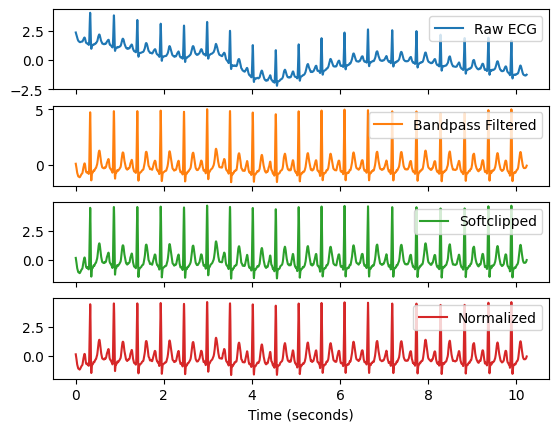

In [3]:
target_fs = 400  # match prepare_dataset.py default
signals, info = wfdb.rdsamp(record_paths[0])
ecg = signals[:, 1]  # use second channel as before
fs = info["fs"]

x = ecg[None, :].astype(float)  # (1, T) so resample_ecg works
x = butter_filter(x, sample_rate=fs, lower_freq=0.67, upper_freq=45.0, order=1.5)
x, _ = resample_ecg(x, sample_rate=int(fs), target_sample_rate=target_fs)
x = subtract_channel_medians(x)
ecg_bp = x[0]

# Demo bounds per-record (dataset-wide bounds come from the metadata folds)
p1 = np.percentile(ecg_bp, 1)
p99 = np.percentile(ecg_bp, 99)
T = float(max(abs(p1), p99))

ecg_bp_sc = softclip_scale_ecg(ecg_bp[None, :], a=-T, b=T, c=T)[0]
ecg_bp_sc_norm = normalize_per_lead(ecg_bp_sc[None, :])[0]

nk.signal_plot(
    signal=[ecg, ecg_bp, ecg_bp_sc, ecg_bp_sc_norm],
    sampling_rate=target_fs,
    subplots=True,
    labels=["Raw ECG", "Bandpass Filtered", "Softclipped", "Normalized"],
    standardize=True,
)


## Frequency Content
By using the cleaning function from Biosppy, high frequency noise as well as low frequency noise is being removed from the signal.

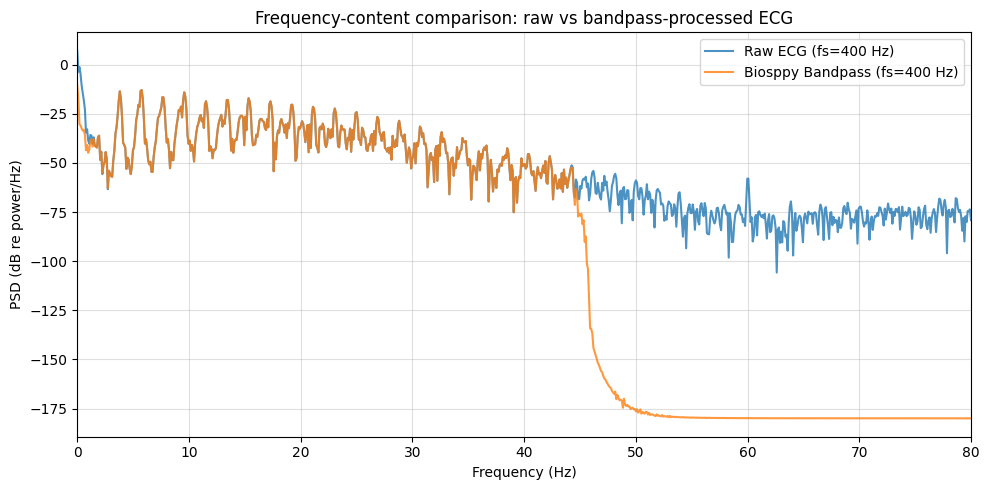

In [4]:
# Frequency-response comparison: raw ECG (ecg, fs) vs bandpass-processed (ecg_bp, target_fs)
# Uses numpy FFT-based PSD estimate with a Hann window. Relies on variables already defined in the notebook:
# ecg, ecg_bp, fs, target_fs, np, plt

def compute_psd(signal, sr):
    n = signal.shape[0]
    win = np.hanning(n)
    fft = np.fft.rfft(signal * win)
    # PSD normalization approximating units of power/Hz
    psd = (np.abs(fft) ** 2) / (sr * np.sum(win ** 2))
    freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    return freqs, psd

# compute PSDs
f_raw, psd_raw = compute_psd(ecg.astype(float), fs)
f_bp, psd_bp = compute_psd(ecg_bp.astype(float), target_fs)

# limit frequency range for plotting (ECG content mostly below ~100 Hz)
fmax = 80.0
mask_raw = f_raw <= fmax
mask_bp = f_bp <= fmax

# convert to dB for clearer comparison
eps = 1e-18
psd_raw_db = 10 * np.log10(psd_raw + eps)
psd_bp_db = 10 * np.log10(psd_bp + eps)

plt.figure(figsize=(10, 5))
plt.plot(f_raw[mask_raw], psd_raw_db[mask_raw], label=f"Raw ECG (fs={fs} Hz)", alpha=0.8)
plt.plot(f_bp[mask_bp], psd_bp_db[mask_bp], label=f"Biosppy Bandpass (fs={target_fs} Hz)", alpha=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB re power/Hz)")
plt.title("Frequency-content comparison: raw vs bandpass-processed ECG")
plt.xlim(0, fmax)
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## ECG Quality

To quickly assess the ECG quality, I use `ecg_quality()` from `neurokit2`.
Two different metrics are obtained here via different methods:
- `templatematch` assesses how consistnet a signal is and assigns a score between 0 and 1
- `zhao2018` assigns one of `Unacceptable`, `Barely acceptable`, `Excellent`

In [5]:
# Compute and print ECG quality at each processing step
qc_raw_zhao = nk.ecg_quality(ecg, sampling_rate=fs, method="zhao2018", approach="simple")
qc_raw_tm = float(np.median(nk.ecg_quality(ecg, sampling_rate=fs, method="templatematch", approach="simple")))

qc_bp_zhao = nk.ecg_quality(ecg_bp, sampling_rate=fs, method="zhao2018", approach="simple")
qc_bp_tm = float(np.median(nk.ecg_quality(ecg_bp, sampling_rate=fs, method="templatematch", approach="simple")))

qc_bp_sc_zhao = nk.ecg_quality(ecg_bp_sc, sampling_rate=fs, method="zhao2018", approach="simple")
qc_bp_sc_tm = float(np.median(nk.ecg_quality(ecg_bp_sc, sampling_rate=fs, method="templatematch", approach="simple")))

qc_bp_sc_norm_zhao = nk.ecg_quality(ecg_bp_sc_norm, sampling_rate=fs, method="zhao2018", approach="simple")
qc_bp_sc_norm_tm = float(np.median(nk.ecg_quality(ecg_bp_sc_norm, sampling_rate=fs, method="templatematch", approach="simple")))

print("Raw ECG Quality (Zhao 2018):", qc_raw_zhao)
print("Raw ECG Quality (Template Match):", qc_raw_tm)
print()
print("Bandpass ECG Quality (Zhao 2018):", qc_bp_zhao)
print("Bandpass ECG Quality (Template Match):", qc_bp_tm)
print()
print("Softclipped ECG Quality (Zhao 2018):", qc_bp_sc_zhao)
print("Softclipped ECG Quality (Template Match):", qc_bp_sc_tm)
print()
print("Normalized ECG Quality (Zhao 2018):", qc_bp_sc_norm_zhao)
print("Normalized ECG Quality (Template Match):", qc_bp_sc_norm_tm)

Raw ECG Quality (Zhao 2018): Barely acceptable
Raw ECG Quality (Template Match): 0.9870500835526301

Bandpass ECG Quality (Zhao 2018): Excellent
Bandpass ECG Quality (Template Match): 0.9964678254383373

Softclipped ECG Quality (Zhao 2018): Excellent
Softclipped ECG Quality (Template Match): 0.9963032528204763

Normalized ECG Quality (Zhao 2018): Barely acceptable
Normalized ECG Quality (Template Match): 0.9963032528204756


## Further Exploration

Neurokit also offers beat extraction and delineatin, but no further usage of these was made for my preprocessing.

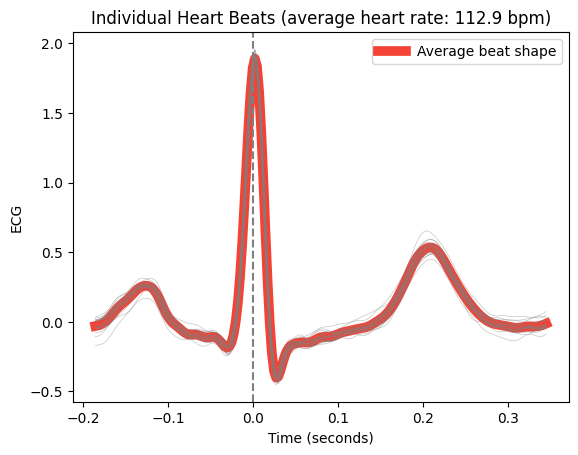

In [6]:
# Plotting all the heart beats
epochs = nk.ecg_segment(ecg_bp, rpeaks=None, sampling_rate=fs, show=True)


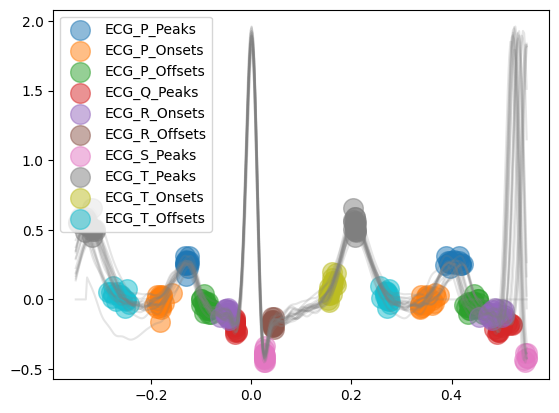

In [7]:
_, rpeaks = nk.ecg_peaks(ecg_bp, sampling_rate=fs)
# Delineate the ECG signal and visualizing all peaks of ECG complexes
_, waves_peak = nk.ecg_delineate(
    ecg_bp,
    rpeaks,
    sampling_rate=fs,
    method="dwt",
    show=True,
    show_type="all",
)
